# **<span style="color:#682F2F;"><center>DIMENSÕES ROTULADAS DE UM DIAMANTE</center></span>**

<div style="border-radius:10px;
border : #682F2F solid;
background-color:#FFF8DC;
font-size:110%;
text-align: left">

## <h2 style='border:0; color:#682F2F'><center>Sobre os dados (Descrição dos atributos)</center></h2>

**Este dataset clássico contém os preços e outros atributos de quase 54.000 diamantes. Existem 10 atributos incluídos no conjunto de dados, incluindo o alvo (target), ou seja, o preço.**

* **carat (0.2-5.01):** O *carat* (quilate) é o peso físico do diamante medido em quilates métricos. Um quilate equivale a 0,20 gramas e é subdividido em 100 pontos.
* **cut (Fair, Good, Very Good, Premium, Ideal):** A qualidade do corte (lapidação). Quanto mais preciso for o corte do diamante, mais cativante ele é aos olhos, sendo assim de grau mais elevado.
* **color (de J (pior) a D (melhor)):** A cor dos diamantes com qualidade de gema ocorre em muitos matizes. Varia de incolor a amarelo claro ou marrom claro. Diamantes incolores são os mais raros. Outras cores naturais (azul, vermelho, rosa, por exemplo) são conhecidas como "fancy" (fantasia), e sua graduação de cor é diferente da dos diamantes brancos incolores.
* **clarity (I1 (pior), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (melhor)):** A pureza/clareza. Diamantes podem ter características internas conhecidas como inclusões ou características externas conhecidas como manchas. Diamantes sem inclusões ou manchas são raros; no entanto, a maioria das características só pode ser vista com ampliação.
* **depth (43-79)**: É a porcentagem de profundidade total que equivale a z / média(x, y) = 2 * z / (x + y). A profundidade do diamante é sua altura (em milímetros) medida do cúlase (*culet* - ponta inferior) até a mesa (superfície plana superior), conforme indicado no diagrama rotulado acima.
* **table (43-95):** É a largura do topo do diamante (mesa) em relação ao ponto mais largo. Ela confere ao diamante um fogo e brilho deslumbrantes ao refletir a luz em todas as direções, o que, quando visto por um observador, parece lustroso.
* **price ($$326 - $18826):** É o preço do diamante em dólares americanos. **É a nossa coluna alvo (target) no dataset.**
* **x (0 - 10.74):** Comprimento do diamante (em mm)
* **y (0 - 58.9):** Largura do diamante (em mm)
* **z (0 - 31.8):** Profundidade do diamante (em mm)

<a id = "title-one"><a>
<h1 style='background:#682F2F; border:0; border-radius: 10px; color:white'><center>IMPORTING LIBRARIES<center><h1>

In [23]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [25]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn. linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn import metrics 
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score, root_mean_squared_error

<a id = "title-two"></a>
<h1 style='background:#682F2F; border:0; border-radius: 10px; color:white'><center>LOADING DATA</center></h1>

In [4]:
data_df = pd.read_csv("C:/Users/bianc/OneDrive/Documents/1-Estudos/2-DNC/1-Data Science/1-Material/Materis9-Modelos_de_Classificacao_Regressao/IA para Ciência de Dados/diamonds.csv")
data_df.sample(10)  

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
5406,5407,1.00,Good,E,SI2,63.7,61.0,3819,6.27,6.32,4.01
25221,25222,1.70,Ideal,H,VS1,62.4,55.0,13823,7.61,7.69,4.77
6476,6477,0.90,Good,E,SI1,62.4,62.0,4054,6.13,6.17,3.84
50047,50048,0.70,Very Good,H,SI1,61.5,55.0,2200,5.72,5.76,3.53
8021,8022,1.25,Premium,J,SI2,62.3,59.0,4331,6.82,6.86,4.26
47579,47580,0.60,Ideal,F,VS2,61.9,55.0,1875,5.43,5.46,3.37
36595,36596,0.30,Ideal,F,IF,62.0,56.0,947,4.30,4.34,2.68
3883,3884,1.01,Good,I,VS1,64.2,60.0,3484,6.35,6.27,4.05
23692,23693,1.50,Good,D,SI1,63.1,57.0,11756,7.24,7.31,4.59
14722,14723,0.30,Premium,H,VVS2,62.0,58.0,605,4.30,4.35,2.68


<a id = "title-three"></a>
<h1 style='background: #682F2F; border:0; border-radius: 10px; color:white'><center>DATA ANALYSIS</center></h1>

### **<span style="color:#682F2F;"><center>Checking for missing values & categorical variables</center></span>**

In [5]:
# Checking for missing values and categorical variables in the dataset
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB




### **<span style="color:#682F2F;">Nota: </span>**

##### Existem 53.940 valores não nulos em todos os atributos, portanto, não há valores ausentes.

##### O tipo de dado das features 'cut', 'color' e 'clarity' é "object", o que precisa ser convertido em variável numérica (será feito no pré-processamento de dados) antes de alimentarmos os dados aos algoritmos.



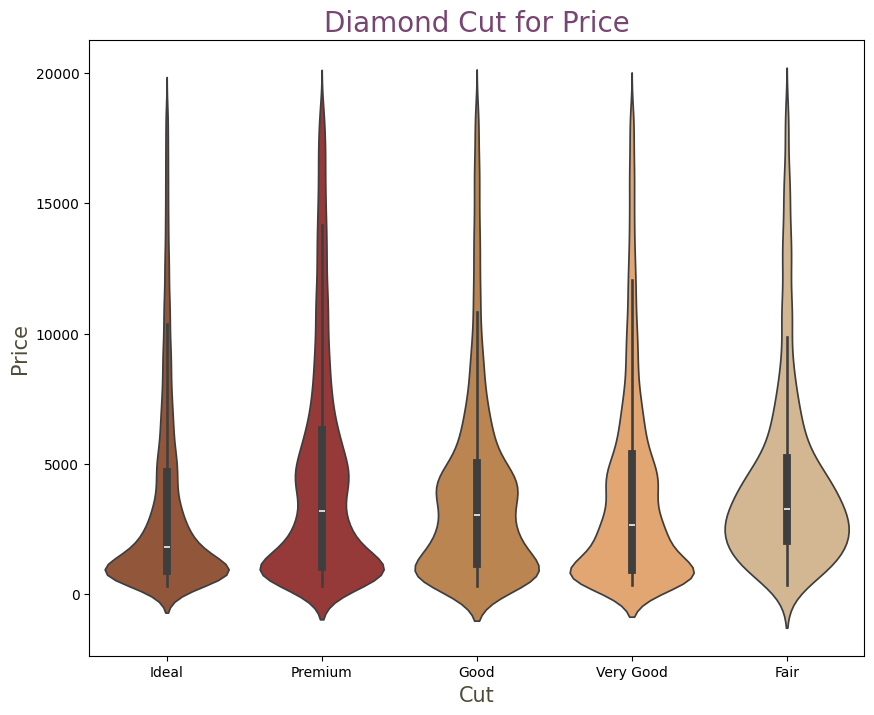

In [6]:
plt.figure(figsize=(10,8))
cols = ["#A0522D","#A52A2A","#CD853F","#F4A460","#DEB887"]
ax = sns.violinplot(x="cut",y="price", data=data_df, palette=cols,scale= "count")
ax.set_title("Diamond Cut for Price", color="#774571", fontsize = 20)
ax.set_ylabel("Price", color="#4e4c39", fontsize = 15)
ax.set_xlabel("Cut", color="#4e4c39", fontsize = 15)
plt.show()

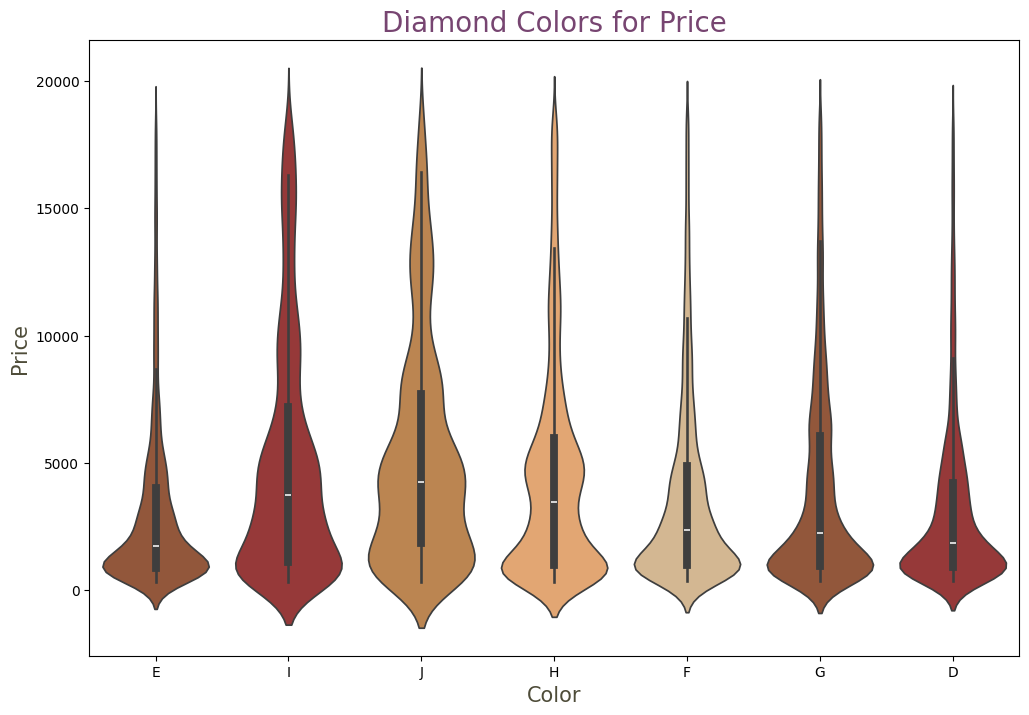

In [7]:
plt.figure(figsize=(12,8))
ax = sns.violinplot(x="color",y="price", data=data_df, palette=cols,scale= "count")
ax.set_title("Diamond Colors for Price", color="#774571", fontsize = 20)
ax.set_ylabel("Price", color="#4e4c39", fontsize = 15)
ax.set_xlabel("Color", color="#4e4c39", fontsize = 15)
plt.show()

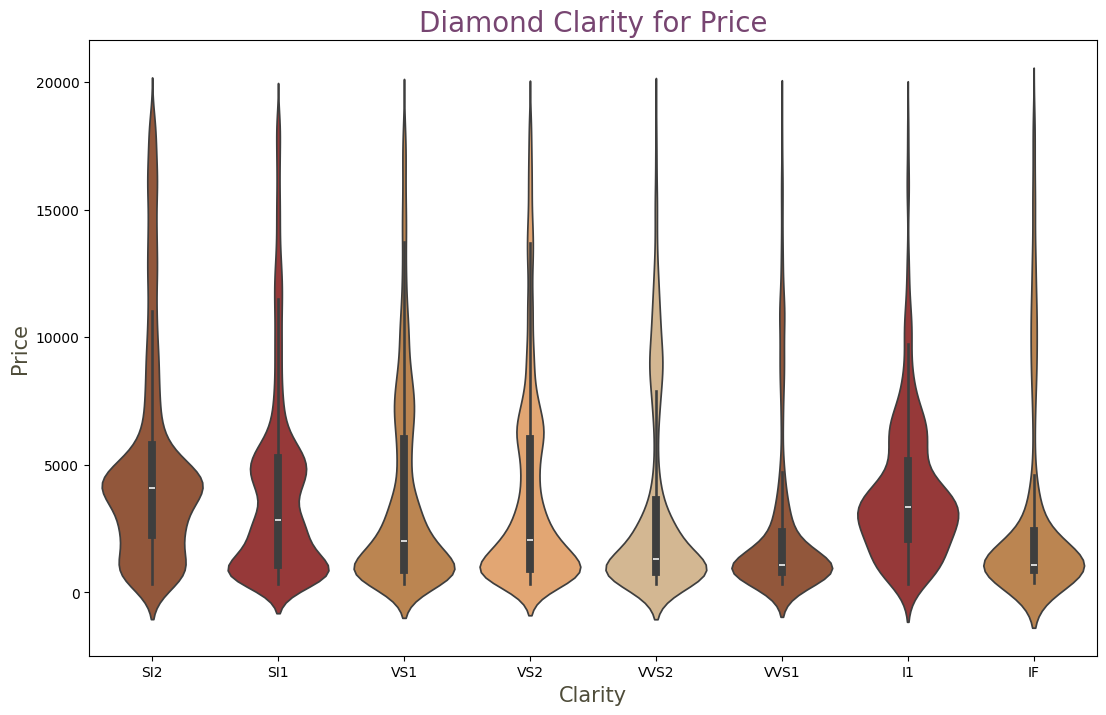

In [8]:
plt.figure(figsize=(13,8))
ax = sns.violinplot(x="clarity",y="price", data=data_df, palette=cols,scale= "count")
ax.set_title("Diamond Clarity for Price", color="#774571", fontsize = 20)
ax.set_ylabel("Price", color="#4e4c39", fontsize = 15)
ax.set_xlabel("Clarity", color="#4e4c39", fontsize = 15)
plt.show()


### **<span style="color:#682F2F;">Nota: </span>**

##### Cortes de diamante "Ideal" são a maioria em quantidade, enquanto "Fair" (Aceitável) são a minoria. Há mais diamantes de todos esses cortes na categoria de preço mais baixo.

##### Diamantes de cor "J", que é a pior, são os mais raros; no entanto, "H" e "G" existem em maior número, embora também sejam de qualidade inferior.

##### Diamantes de pureza "IF", que é a melhor, bem como "I1", que é a pior, são muito raros, e o restante é, em sua maioria, de purezas intermediárias.



### **<span style="color:#682F2F;"><center>Descriptive Statistics</center></span>**

In [9]:
# Doing Univariate Analysis for statistical description and understanding of dispersion of data
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,53940.0,26970.500000,15571.281097,1.0,13485.75,26970.50,40455.25,53940.00
carat,53940.0,0.797940,0.474011,0.2,0.40,0.70,1.04,5.01
depth,53940.0,61.749405,1.432621,43.0,61.00,61.80,62.50,79.00
table,53940.0,57.457184,2.234491,43.0,56.00,57.00,59.00,95.00
price,53940.0,3932.799722,3989.439738,326.0,950.00,2401.00,5324.25,18823.00
x,53940.0,5.731157,1.121761,0.0,4.71,5.70,6.54,10.74
y,53940.0,5.734526,1.142135,0.0,4.72,5.71,6.54,58.90
z,53940.0,3.538734,0.705699,0.0,2.91,3.53,4.04,31.80


### **<span style="color:#682F2F;">Nota: </span>**

##### "Price" (Preço), como esperado, possui assimetria à direita (*right skewed*), tendo um maior número de pontos de dados à esquerda.

##### Nas features dimensionais 'x', 'y' e 'z' - o valor mínimo é 0, tornando tais pontos de dados objetos de diamante 1D ou 2D, o que não faz muito sentido - portanto, precisam ser imputados com um valor apropriado ou descartados completamente.

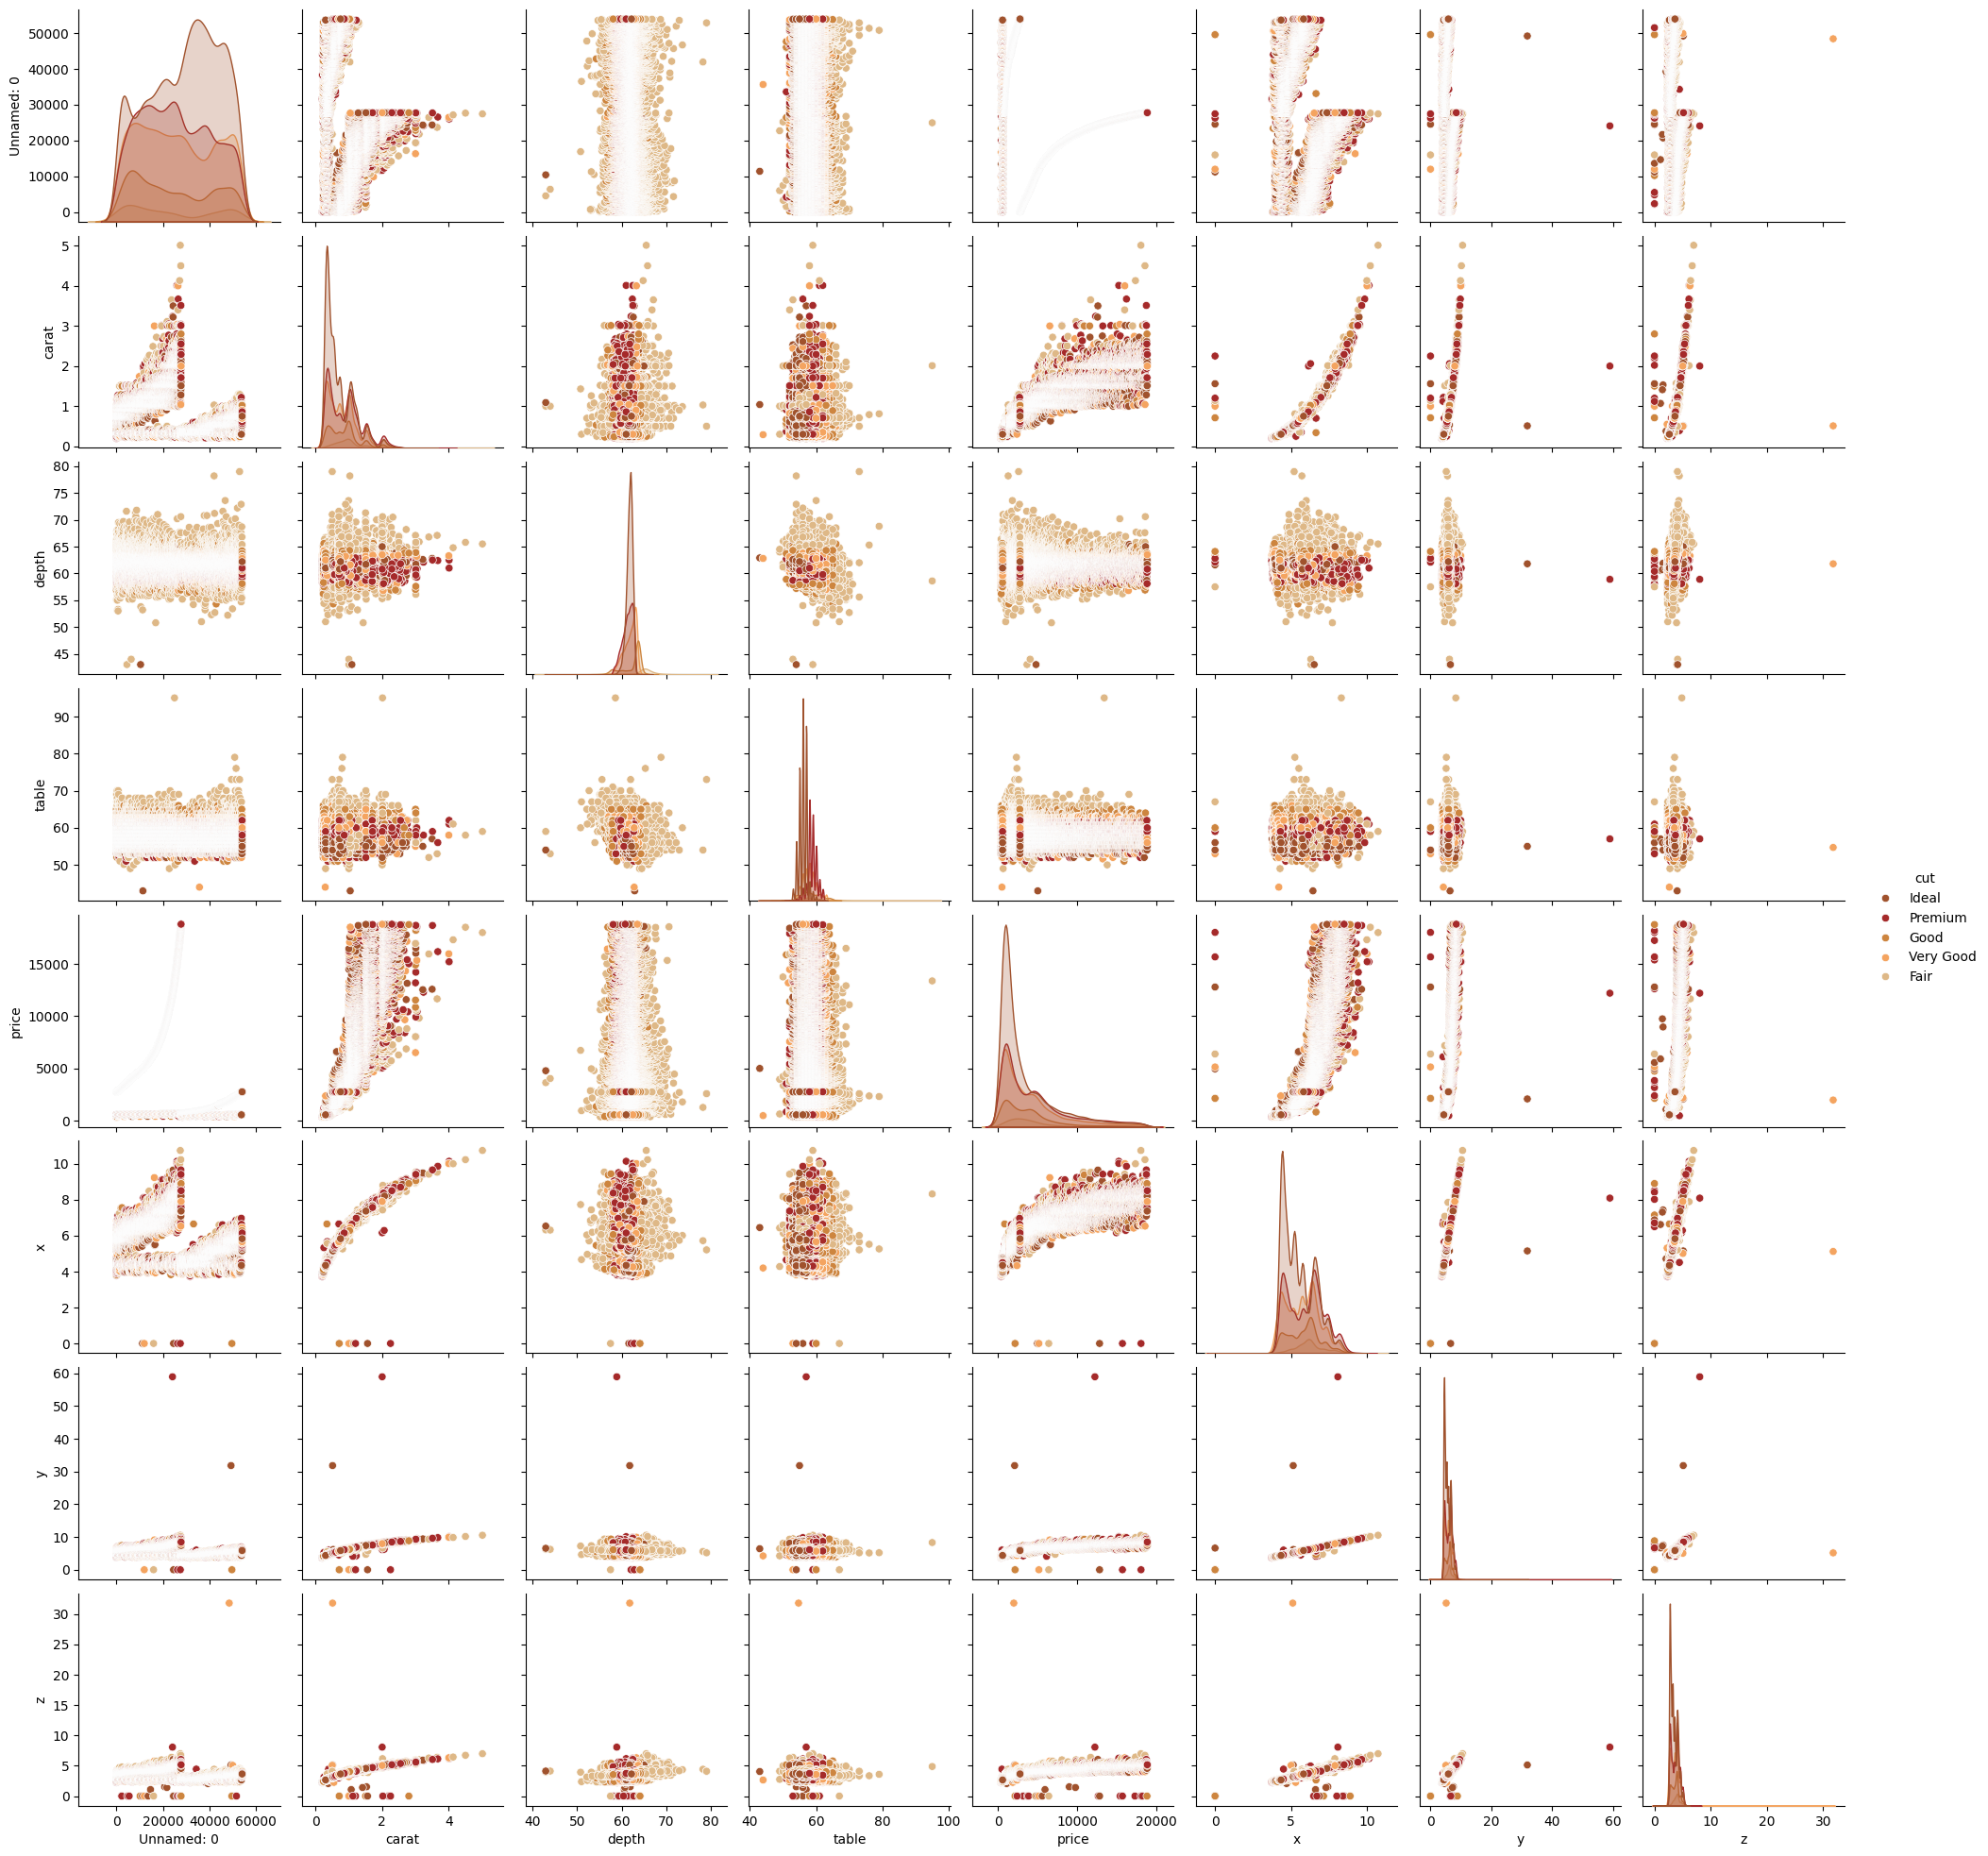

In [10]:
#Doing Bivariate Analysis by examaning a pairplot  
ax = sns.pairplot(data_df, hue= "cut", palette = cols)

### **<span style="color:#682F2F;">Nota: </span>**

##### Existe uma feature inútil "unnamed" que é apenas um índice e precisa ser eliminada completamente.

##### As features possuem pontos de dados que estão longe do resto do dataset (outliers), os quais precisam ser tratados, ou então afetarão nosso modelo.

##### "y" e "z" têm alguns outliers dimensionais em nosso dataset que precisam ser eliminados.

##### As features "depth" e "table" devem ser limitadas (*capped*) após confirmarmos examinando os gráficos de linha (*Line plots*).

### **<span style="color:#682F2F;"><center>Checking for Potential Outliers</center></span>**

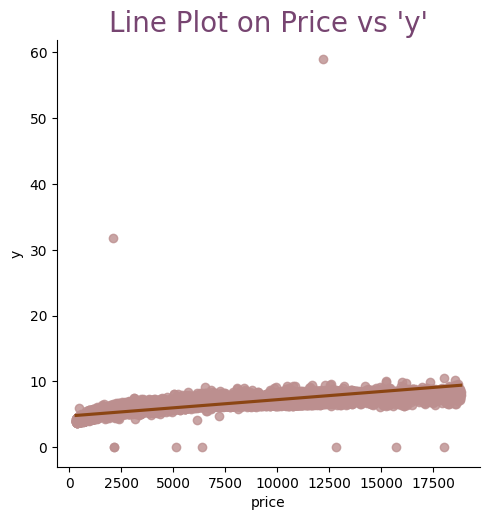

In [11]:
lm = sns.lmplot(x="price", y="y", data=data_df, scatter_kws={"color": "#BC8F8F"}, line_kws={"color": "#8B4513"})
plt.title("Line Plot on Price vs 'y'", color="#774571", fontsize = 20)
plt.show()

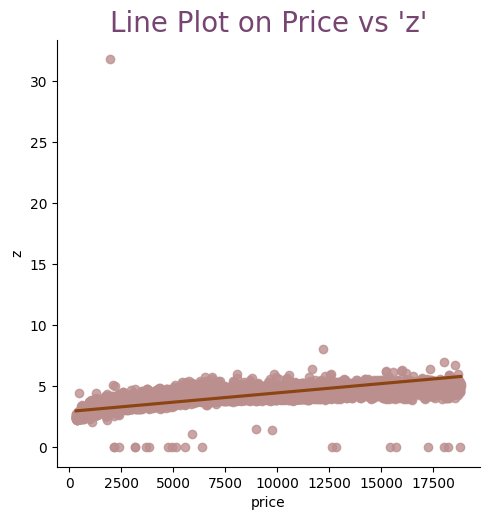

In [12]:
lm = sns.lmplot(x="price", y="z", data=data_df, scatter_kws={"color": "#BC8F8F"}, line_kws={"color": "#8B4513"})
plt.title("Line Plot on Price vs 'z'", color="#774571", fontsize = 20)
plt.show()

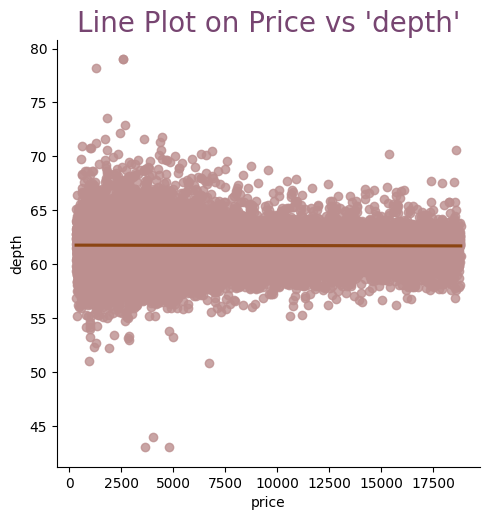

In [13]:
lm = sns.lmplot(x="price", y="depth", data=data_df, scatter_kws={"color": "#BC8F8F"}, line_kws={"color": "#8B4513"})
plt.title("Line Plot on Price vs 'depth'", color="#774571", fontsize = 20)
plt.show()

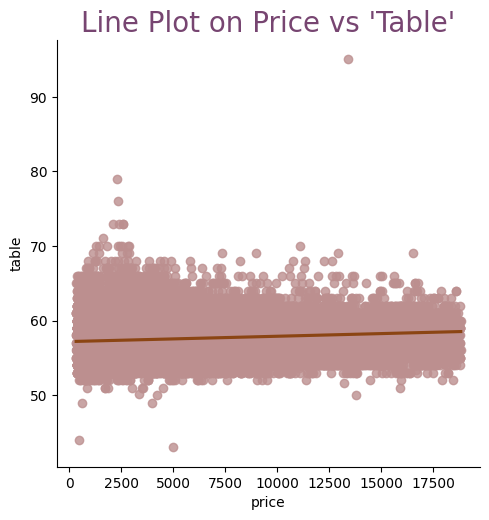

In [14]:
lm = sns.lmplot(x="price", y="table", data=data_df, scatter_kws={"color": "#BC8F8F"}, line_kws={"color": "#8B4513"})
plt.title("Line Plot on Price vs 'Table'", color="#774571", fontsize = 20)
plt.show()

<a id = "title-four"></a>
<h1 style='background: #682F2F; border:0; border-radius: 10px; color:white'><center>DATA PREPROCESSING</center></h1>

### **<span style="color:#682F2F;"><center>Data Cleaning</center></span>**

In [15]:
# Removing the feature "Unnamed"
data_df = data_df.drop(["Unnamed: 0"], axis=1)
data_df.shape

(53940, 10)

In [16]:
# Removing the datapoints having min 0 value in either x, y or z features 
data_df = data_df.drop(data_df[data_df["x"]==0].index)
data_df = data_df.drop(data_df[data_df["y"]==0].index)
data_df = data_df.drop(data_df[data_df["z"]==0].index)
data_df.shape

(53920, 10)

### **<span style="color:#682F2F;"><center>Removing Outliers</center></span>**

In [17]:
# Dropping the outliers (since we have huge dataset) by defining appropriate measures across features 
data_df = data_df[(data_df["depth"]<75)&(data_df["depth"]>45)]
data_df = data_df[(data_df["table"]<80)&(data_df["table"]>40)]
data_df = data_df[(data_df["x"]<40)]
data_df = data_df[(data_df["y"]<40)]
data_df = data_df[(data_df["z"]<40)&(data_df["z"]>2)]
data_df.shape 

(53909, 10)

### **<span style="color:#682F2F;"><center>Encoding Categorical Variables</center></span>**

In [18]:
# Making a copy to keep original data in its form intact
data1 = data_df.copy()

# Applying label encoder to columns with categorical data
columns = ['cut','color','clarity']
label_encoder = LabelEncoder()
for col in columns:
    data1[col] = label_encoder.fit_transform(data1[col])
data1.describe()

,carat,cut,color,clarity,depth,table,price,x,y,z
count,53909.000000,53909.000000,53909.000000,53909.000000,53909.000000,53909.000000,53909.000000,53909.000000,53909.000000,53909.000000
mean,0.797617,2.553396,2.593964,3.835575,61.749743,57.455852,3930.513680,5.731441,5.733764,3.539994
std,0.473759,1.027444,1.701283,1.724540,1.420093,2.226169,3987.145802,1.119369,1.116891,0.702085
min,0.200000,0.000000,0.000000,0.000000,50.800000,43.000000,326.000000,3.730000,3.680000,2.060000
25%,0.400000,2.000000,1.000000,2.000000,61.000000,56.000000,949.000000,4.710000,4.720000,2.910000
50%,0.700000,2.000000,3.000000,4.000000,61.800000,57.000000,2400.000000,5.700000,5.710000,3.530000
75%,1.040000,3.000000,4.000000,5.000000,62.500000,59.000000,5322.000000,6.540000,6.540000,4.040000
max,5.010000,4.000000,6.000000,7.000000,73.600000,79.000000,18823.000000,10.740000,31.800000,31.800000


Aqui está a tradução para Português (Brasil), mantendo a formatação e o estilo original:

### **<span style="color:#682F2F;">Nota: </span>**

##### Como as features categóricas foram convertidas em colunas numéricas, estamos obtendo o resumo de 5 pontos (*5-point summary*) juntamente com contagem, média e desvio padrão para elas também.

##### Agora, podemos analisar a matriz de correlação após a conclusão do pré-processamento para uma possível seleção de features (*feature selection*), a fim de tornar nosso dataset mais limpo e otimizado antes de alimentá-lo no algoritmo.

### **<span style="color:#682F2F;"><center>Correlation Matrix</center></span>**

<Axes: >

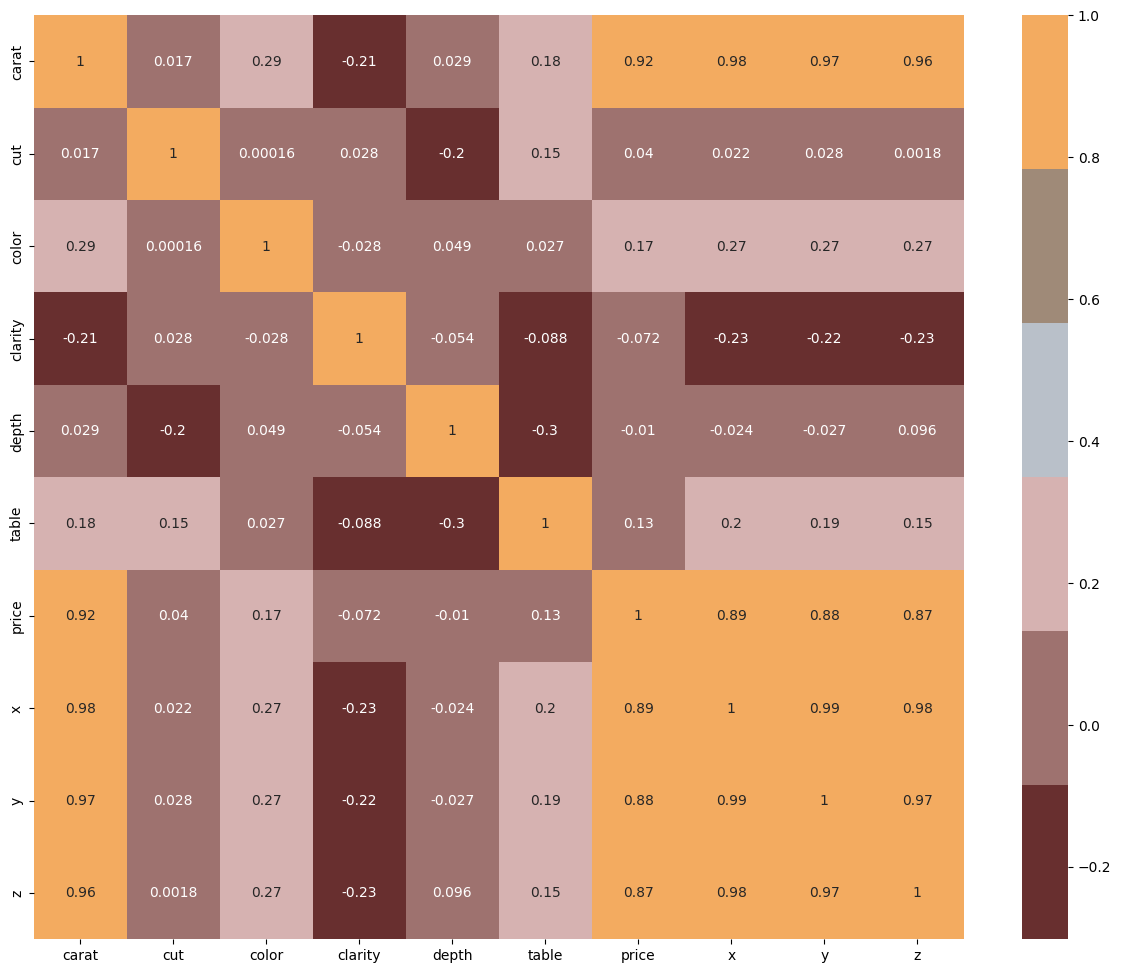

In [19]:
# Examining correlation matrix using heatmap
cmap = sns.diverging_palette(205, 133, 63, as_cmap=True)
cols = (["#682F2F", "#9E726F", "#D6B2B1", "#B9C0C9", "#9F8A78", "#F3AB60"])
corrmat= data1.corr()
f, ax = plt.subplots(figsize=(15,12))
sns.heatmap(corrmat,cmap=cols,annot=True)


### **<span style="color:#682F2F;">Nota: </span>**

##### As features "carat", "x", "y", "z" são altamente correlacionadas à nossa variável alvo, o preço.

##### As features "cut", "clarity", "depth" possuem uma correlação muito baixa (<|0.1|), portanto, poderiam ser removidas; no entanto, devido à presença de apenas algumas features selecionadas, não faremos isso.

<a id = "title-five"></a>
<h1 style='background: #682F2F; border:0; border-radius: 10px; color:white'><center>MODEL BUILDING</center></h1>

In [20]:
# Defining the independent and dependent variables
X= data1.drop(["price"],axis =1)
y= data1["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20, random_state=25)

In [26]:
# Building pipelins of standard scaler and model for varios regressors.

pipeline_lr=Pipeline([("scalar1",StandardScaler()),
                     ("lr",LinearRegression())])

pipeline_lasso=Pipeline([("scalar2", StandardScaler()),
                      ("lasso",Lasso())])

pipeline_dt=Pipeline([("scalar3",StandardScaler()),
                     ("dt",DecisionTreeRegressor())])

pipeline_rf=Pipeline([("scalar4",StandardScaler()),
                     ("rf",RandomForestRegressor())])


pipeline_kn=Pipeline([("scalar5",StandardScaler()),
                     ("kn",KNeighborsRegressor())])


pipeline_xgb=Pipeline([("scalar6",StandardScaler()),
                     ("xgb",XGBRegressor())])

# List of all the pipelines
pipelines = [pipeline_lr, pipeline_lasso, pipeline_dt, pipeline_rf, pipeline_kn, pipeline_xgb]

# Dictionary of pipelines and model types for ease of reference
pipeline_dict = {0: "LinearRegression", 1: "Lasso", 2: "DecisionTree", 3: "RandomForest",4: "KNeighbors", 5: "XGBRegressor"}

# Fit the pipelines
for pipe in pipelines:
    pipe.fit(X_train, y_train)

In [27]:
cv_results_rms = []
for i, model in enumerate(pipelines):
    cv_score = cross_val_score(model, X_train,y_train,scoring="neg_root_mean_squared_error", cv=12)
    cv_results_rms.append(cv_score)
    print("%s: %f " % (pipeline_dict[i], -1 * cv_score.mean()))

LinearRegression: 1383.854012 
Lasso: 1366.991298 
DecisionTree: 735.475111 
RandomForest: 549.492771 
KNeighbors: 816.559279 
XGBRegressor: 548.346842 


In [28]:
# Model prediction on test data with XGBClassifier which gave us the least RMSE 
pred = pipeline_xgb.predict(X_test)
print("R^2:",metrics.r2_score(y_test, pred))
print("Adjusted R^2:",1 - (1-metrics.r2_score(y_test, pred))*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

R^2: 0.9821290969848633
Adjusted R^2: 0.9821141658553483


## **<span style="color:#682F2F;">Great! We got 98.27% accuracy with it. We can take the model into production. </span>**

<a id = "title-six"></a>
<h1 style='background: #682F2F; border:0; border-radius: 10px; color:white'><center>END</center></h1>